In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time, sys, os

sys.path.append(os.path.abspath("../src"))

from sampling import samp
from integrals_roots import integrals

plt.rcParams['figure.figsize'] = [6.0, 3.8]

## Sampling + Non-Gradient Minimization

Take the function

$$V(x) = \frac{x^{2}}{10} + \sin(x) + e^{-5x^{2}}$$

For many reasons, we might want to minimize this function. For example, it could
describe the cost from a predictive model (with one weight which is kind of silly),
or the energy of a sampling distribution (as it is used in the other notebook), in 
which case the minumum would be the mode.

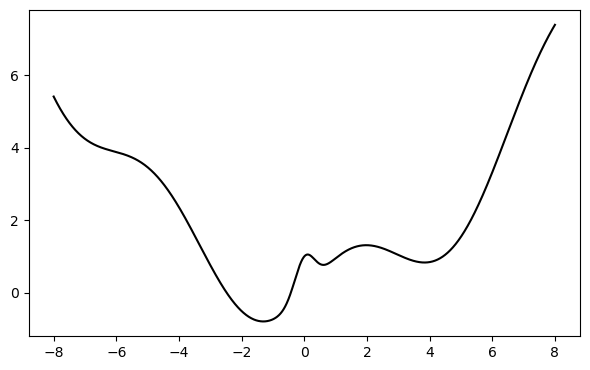

Z = 6.497698


In [6]:
v = lambda x: (
    (x**2 / 10) + (np.sin(x)) + (np.exp(-5*(x**2)))
)

z = integrals.midpoint_area(lambda x: np.exp(-v(x)), -10, 10, 20_000)

p = lambda x: (
    (1 / z) * (np.exp(-v(x)))
)

xs = np.linspace(-8, 8, 2_000)

plt.plot(xs, v(xs), color = "black")

plt.tight_layout()
plt.show()

print(f"Z = {z:.6f}")

### Simulated annealing

Gradient descent walks downhill and stops at the first minimum it reaches, which for a $V$ like this one means stopping near wherever you happened to start. Annealing works to fix that by letting the walk go uphill sometimes, while making it less willing to do so as time goes on (such that it still converges). The name comes from blacksmithing: cool a metal slowly and its atoms have time to settle into a low energy lattice, quench it and they freeze wherever they were (this is also where "temperature" gets its name from below).

Starting from $x^{(1)} = 0$, propose a step $x' = x^{(k)} + \epsilon$ with $\epsilon \sim N(0, 1)$ (or some other distribution), and accept it with probability

$$\alpha = \min\left(1,\; e^{-\frac{V(x') - V(x^{(k)})}{T_{k}}}\right) $$

Where $T_{k}$ is the temperature of the $k^{th}$ sample, defined by some decreasing --- typically logarithmicaly --- function. In this case:

$$T_{k} = \frac{10}{\ln(k + 1)}$$

Downhill proposals make the exponent positive and are always taken. Uphill proposals are taken with a probability that depends on how steep the move is relative to the current temperature, so early on the walk wanders nearly freely and later it mostly refuses to climb.

Some notes about the actual implimentation:

The $\min(1, \cdot)$ never has to be written down. Sampling $u \sim U(0, 1)$ and accepting when $u <$ the exponential handles it on its own, since a $u$ drawn from $[0, 1)$ is always below anything greater than 1.

The above logarithmic temperature schedule is slow on purpose, and 1000 iterations barely dents it. $T_{1} \approx 14.4$ and $T_{1000} \approx 1.45$, so even at the end an uphill move costing 1 in $V$ is still accepted about half the time. For small numbers of iterations, the walk never freezes, so in this implimentation (with $n = 1,000$) is why the best point found has to be stored separately instead of read off the final state (which isn't even necissarily a local minimum). 

```python
def annealing(v, iterations):
    x = 0
    best = (x, v(x), 0)

    for k in range(iterations):
        proposed = x + normal()

        if random() < exp((v(x) - v(proposed)) / t(k)):
            if v(proposed) < best[1]:
                best = (proposed, v(proposed), k + 1)
            x = proposed

    return best
```

In [ ]:
start = time.perf_counter_ns()

x_star, v_star, found_at = samp.annealing(v, iterations = 10**3)

annealing_time = (time.perf_counter_ns() - start) * 1e-6

print(f"x*      = {x_star:.6f}")
print(f"V(x*)   = {v_star:.6f}")
print(f"found at iteration {found_at} of 1000")
print(f"runtime: {annealing_time:.2f} ms")

x*      = -1.308588
V(x*)   = -0.794388
found at iteration 431664 of 1000
runtime: 7100.59 ms


Checking that against a brute force scan of $V$ over 200,001 evenly spaced points, annealing is significantly slower and more innacurate. In practice, annealing is used in much higher dimensional loss functions (similar to gradient decent), such as machine learning.

In [ ]:
grid = np.linspace(-10, 10, 200_001)
grid_v = v(grid)
grid_min = grid[grid_v.argmin()]

print(f"grid minimum: x = {grid_min:.6f}, V = {grid_v.min():.6f}")
print(f"annealing is off by {abs(x_star - grid_min):.2e}")

grid minimum: x = -1.308600, V = -0.794388
annealing is off by 1.23e-05


One run does not say much about a randomized method, so here it is 200 more times:

x* between -1.3229 and -1.2935
landed within 0.05 of the grid minimum 100% of the time
median iteration where x* was found: 504


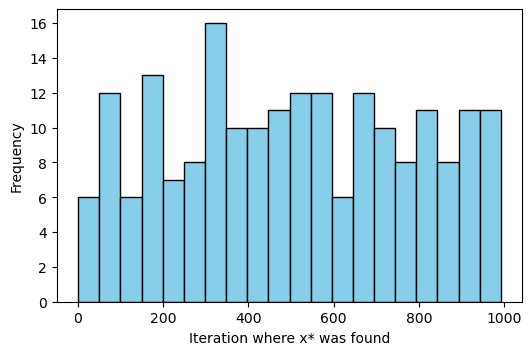

In [ ]:
restarts = [samp.annealing(v, iterations = 10**3) for _ in range(200)]

best = np.array([run[0] for run in restarts])
iteration = np.array([run[2] for run in restarts])

print(f"x* between {best.min():.4f} and {best.max():.4f}")
print(f"landed within 0.05 of the grid minimum {100 * np.mean(np.abs(best - grid_min) < 0.05):.0f}% of the time")
print(f"median iteration where x* was found: {int(np.median(iteration))}")

plt.hist(iteration, bins = 20, color = "skyblue", edgecolor = "black")
plt.xlabel("Iteration where x* was found")
plt.ylabel("Frequency")
plt.show()

$V$ has local minima near $0.61$ and $3.84$ as well as the global one near $-1.31$, and the walk starts at 0, which is on the wrong side of the bump. It still finds the right basin every time. The barriers here are small next to the temperature for almost the whole run, so the chain crosses between wells freely and the schedule never has to be clever about it. A harder function, or one where the minima were separated by larger climbs rather than ones, would put much more weight on the cooling rate and the kernel space ($\epsilon \sim$).

The accuracy is a different story. The spread of $x^{*}$ across restarts is about $\pm 0.02$, which is far finer than the $N(0, 1)$ proposal but is still nothing like the precision of a root finder. Annealing has no refinement step: it is only ever as accurate as the best of its 1000 random shots, so the last couple of digits are luck. Thus annealing is best paired with a more precise method (ex., at each new $x^*$, use gradient decent to find the true local minimum).

The histogram of where $x^{*}$ turns up is a picture of the same tradeoff: early on, the sampling is random, and towards the end it is settleing in whatever local minima it has found.